# Initial Traffic Dataset Analysis

## Overview

This notebook presents an exploratory analysis of the network traffic datasets generated for the IoT Traffic Monitoring & Anomaly Detection System.

The objective is to examine the characteristics of both normal and anomalous traffic before the Machine Learning stage. Through statistical summaries and visualizations, the notebook highlights the main differences between traffic scenarios and validates the extracted features used later by the anomaly detection models.

The analysis includes:

- Loading the generated datasets.

- Exploring normal and anomalous traffic.

- Comparing statistical distributions.

- Visualizing feature relationships.

- Identifying traffic patterns associated with different anomaly scenarios.

> **Note:** The complete processing pipeline, feature extraction and Machine Learning implementation are available in the `src/` directory. This notebook is intended exclusively for exploratory data analysis (EDA).

## Library Import and Dataset Loading

This section imports the Python libraries required for the exploratory analysis and loads one of the feature datasets generated by the preprocessing pipeline.

The selected dataset corresponds to normal traffic captured in the simulated domestic IoT environment. It is used to verify that the feature extraction process has been completed successfully and to inspect the structure of the generated data before performing statistical analysis and visualizations.

The following information is displayed:

- Dataset dimensions.

- Available traffic features.

- Preview of the first observations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
normal_df = pd.read_csv("../captures/processed/normal_domestico_processed.csv")

# Display dataset information
print(normal_df.head())

print("\nDataset shape:")
print(normal_df.shape)

print("\nColumns:")
print(normal_df.columns)

      timestamp  packet_length protocol source_ip destination_ip  source_port  \
0  1.766828e+09             52      STP       NaN            NaN          NaN   
1  1.766828e+09             52      STP       NaN            NaN          NaN   
2  1.766828e+09             52      STP       NaN            NaN          NaN   
3  1.766828e+09             52      STP       NaN            NaN          NaN   
4  1.766828e+09             62   ICMPV6       NaN            NaN          NaN   

   destination_port  
0               NaN  
1               NaN  
2               NaN  
3               NaN  
4               NaN  

Dataset shape:
(100, 7)

Columns:
Index(['timestamp', 'packet_length', 'protocol', 'source_ip', 'destination_ip',
       'source_port', 'destination_port'],
      dtype='str')


### Initial Dataset Inspection

The dataset contains **15 time windows** described by **8 statistical traffic features**, indicating that the feature extraction stage has been successfully completed.

The first observations show variability in packet counts, average packet sizes and protocol activity between consecutive time windows. For example, some windows contain a high number of ARP packets, while others present increased ICMP activity. Likewise, the inter-arrival time statistics vary across windows, reflecting differences in communication patterns over time.

Overall, the dataset appears to contain coherent traffic information and is ready for exploratory analysis and visualization in the following sections.

## Initial Traffic Visualization

To obtain an initial understanding of the generated dataset, several visualizations are created for the main traffic features.

These plots provide a first overview of the distribution of packet counts, packet sizes and protocol activity before performing any Machine Learning analysis.

The objective of this exploratory step is to identify visible traffic patterns, detect possible anomalies and verify that the extracted features are consistent with the simulated IoT scenarios.

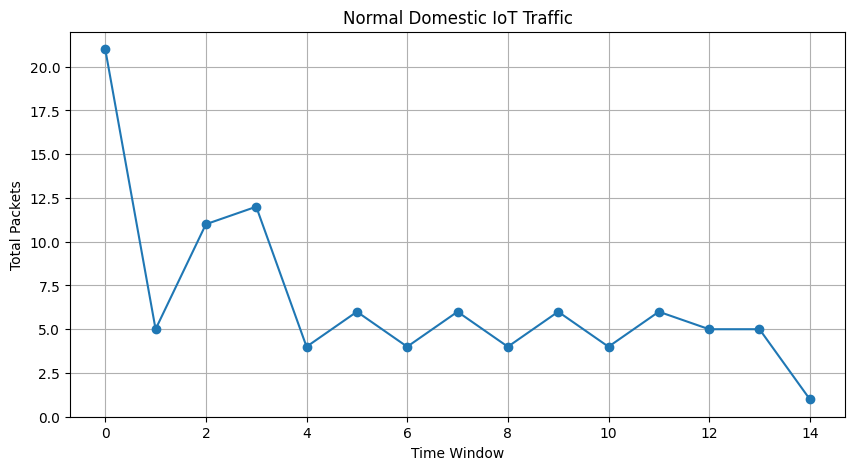

In [8]:
# Traffic volume visualization

normal_df = pd.read_csv("../data/datasets/normal_domestico_dataset.csv")

plt.figure(figsize=(10, 5))

plt.plot(
    normal_df["time_window"],
    normal_df["total_packets"],
    marker="o"
)

plt.title("Normal Domestic IoT Traffic")
plt.xlabel("Time Window")
plt.ylabel("Total Packets")

plt.grid(True)

plt.show()

### Observations

The figure shows the evolution of the number of packets across consecutive time windows for the normal domestic IoT scenario.

A pronounced peak is observed during the first time window, which is expected due to the initial network communication required for device discovery and connection establishment. After this initialization phase, the traffic rapidly stabilizes, with most windows containing between four and six packets.

This relatively constant behaviour is consistent with the periodic communication patterns typically found in normal IoT devices, providing a suitable baseline for later comparison with anomalous traffic scenarios.

## Loading Anomalous Traffic Dataset

To compare normal network behaviour with abnormal conditions, an anomalous traffic dataset is loaded.

The selected capture represents an industrial IoT scenario where communication failures generate abnormal traffic patterns. These events are expected to produce noticeable differences in packet frequency, protocol usage and temporal behaviour compared with normal operation.

The following dataset will be used throughout the remaining analysis.

In [10]:
# Load anomalous traffic dataset

anomaly_df = pd.read_csv("../captures/processed/destino_no_enrutable_industrial_processed.csv")

print(anomaly_df.head())

      timestamp  packet_length protocol source_ip destination_ip  source_port  \
0  1.767008e+09             62   ICMPV6       NaN            NaN          NaN   
1  1.767008e+09             64      ARP       NaN            NaN          NaN   
2  1.767008e+09             64      ARP       NaN            NaN          NaN   
3  1.767008e+09             64      ARP       NaN            NaN          NaN   
4  1.767008e+09             64      ARP       NaN            NaN          NaN   

   destination_port  
0               NaN  
1               NaN  
2               NaN  
3               NaN  
4               NaN  


### Observations

The first rows already reveal substantial differences compared with the normal traffic dataset.

Several time windows contain a high number of ICMP packets, indicating repeated communication failures associated with unreachable destinations. In addition, packet sizes and inter-arrival times exhibit greater variability than in the normal scenario.

These characteristics suggest that the extracted features are capable of capturing abnormal communication behaviour and should provide useful information for the Machine Learning models during anomaly detection.

## Comparison Between Normal and Anomalous Traffic

The following figure compares the evolution of packet activity in a normal domestic IoT scenario and an anomalous industrial IoT scenario.

By analysing the number of packets generated in each time window, it is possible to identify differences in traffic behaviour, communication stability and temporal distribution between both scenarios.

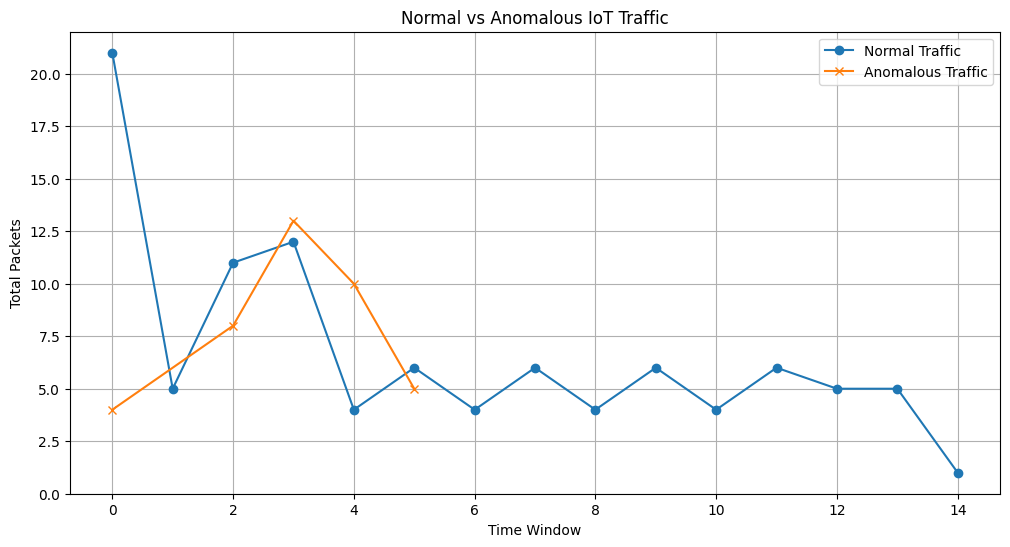

In [12]:
# Compare normal vs anomalous traffic

anomaly_df = pd.read_csv("../data/datasets/destino_no_enrutable_industrial_dataset.csv")

plt.figure(figsize=(12, 6))

plt.plot(
    normal_df["time_window"],
    normal_df["total_packets"],
    marker="o",
    label="Normal Traffic"
)

plt.plot(
    anomaly_df["time_window"],
    anomaly_df["total_packets"],
    marker="x",
    label="Anomalous Traffic"
)

plt.title("Normal vs Anomalous IoT Traffic")
plt.xlabel("Time Window")
plt.ylabel("Total Packets")

plt.legend()
plt.grid(True)

plt.show()

### Observations

The comparison highlights clear differences between the two traffic patterns.

The normal capture exhibits an initial burst of communication followed by a relatively stable packet rate throughout the remaining time windows. This behaviour is consistent with periodic IoT communications once the devices have completed their initialization phase.

In contrast, the anomalous capture shows greater variability during the first windows, with several consecutive peaks in packet activity. These fluctuations are mainly associated with repeated unsuccessful communication attempts, reflected by the increased ICMP traffic observed in the dataset.

Although both scenarios eventually reach similar packet counts, the anomalous traffic presents a less stable temporal behaviour, illustrating how abnormal network events modify the communication pattern even when the overall traffic volume is not dramatically higher.

## Statistical Exploration

A descriptive statistical summary is generated for both datasets to obtain an initial overview of their characteristics.

The summary includes measures such as the mean, standard deviation and value ranges for each extracted feature.

This exploratory step helps identify differences between normal and anomalous traffic before applying Machine Learning techniques.

In [13]:
# Statistical summary

print("=== NORMAL TRAFFIC ===")
print(normal_df.describe())

print("\n=== ANOMALOUS TRAFFIC ===")
print(anomaly_df.describe())

=== NORMAL TRAFFIC ===
       time_window  total_packets  mean_packet_size  std_packet_size  \
count    15.000000      15.000000         15.000000        14.000000   
mean      7.000000       6.666667         55.378066         3.646654   
std       4.472136       4.805751          7.522133         8.314025   
min       0.000000       1.000000         52.000000         0.000000   
25%       3.500000       4.000000         52.000000         0.000000   
50%       7.000000       5.000000         52.000000         0.000000   
75%      10.500000       6.000000         52.000000         0.000000   
max      14.000000      21.000000         75.000000        24.022717   

       icmp_count  arp_count  mean_inter_arrival  std_inter_arrival  
count   15.000000  15.000000           15.000000          14.000000  
mean     0.666667   0.933333            1.296296           0.886707  
std      1.799471   3.104528            0.515580           0.091922  
min      0.000000   0.000000            0.000000

The statistical summary shows noticeable differences between both traffic scenarios.

The anomalous dataset presents higher packet sizes, greater ICMP activity and lower average inter-arrival times than the normal traffic dataset. These differences suggest a more intensive and less regular communication pattern, supporting the use of these features for anomaly detection.

## Packet Distribution Analysis

The distribution of packet volumes is analysed using histograms to compare the traffic generated under normal and anomalous conditions.

This visualization provides an initial overview of the frequency of different traffic intensities and highlights potential shifts in packet volume between both scenarios.

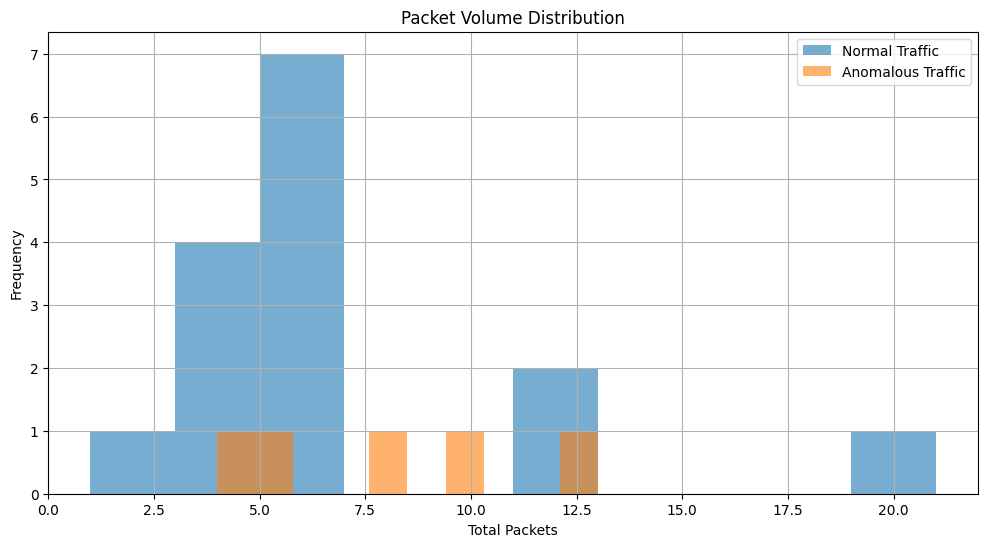

In [14]:
# Histogram comparison

plt.figure(figsize=(12, 6))

plt.hist(
    normal_df["total_packets"],
    bins=10,
    alpha=0.6,
    label="Normal Traffic"
)

plt.hist(
    anomaly_df["total_packets"],
    bins=10,
    alpha=0.6,
    label="Anomalous Traffic"
)

plt.title("Packet Volume Distribution")
plt.xlabel("Total Packets")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()

The histogram shows that normal traffic is mainly concentrated around low packet counts, while the anomalous dataset exhibits a broader distribution with a higher frequency of larger packet volumes.

This behaviour suggests that anomalous traffic generates more variable communication patterns, supporting the hypothesis that packet volume is a useful feature for anomaly detection.

## Traffic Variability and Outlier Analysis

A boxplot is used to compare the variability of packet volumes between normal and anomalous traffic.

This visualization summarizes the median, interquartile range and potential outliers, providing a concise view of traffic dispersion.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_5932\3250235938.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


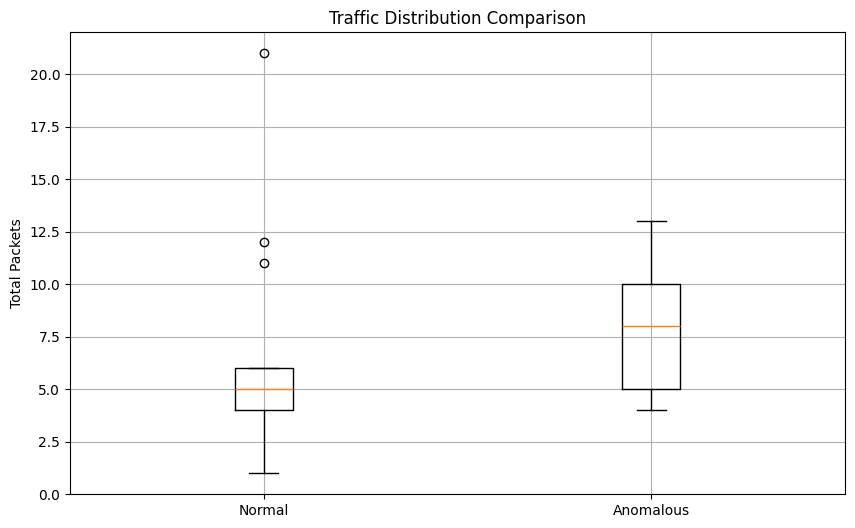

In [15]:
# Boxplot comparison

plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        normal_df["total_packets"],
        anomaly_df["total_packets"]
    ],
    labels=["Normal", "Anomalous"]
)

plt.title("Traffic Distribution Comparison")
plt.ylabel("Total Packets")

plt.grid(True)

plt.show()

The boxplot indicates that anomalous traffic presents a higher median packet count and a wider interquartile range than normal traffic.

Normal traffic includes several isolated high-volume observations, whereas anomalous traffic remains consistently concentrated at higher packet counts. These differences further support the discriminative capability of the extracted traffic features.

## Feature Correlation Analysis

A correlation matrix is generated to examine the relationships among the extracted traffic features.

Identifying correlated variables helps to better understand traffic behaviour and provides insight into the information available for Machine Learning models.

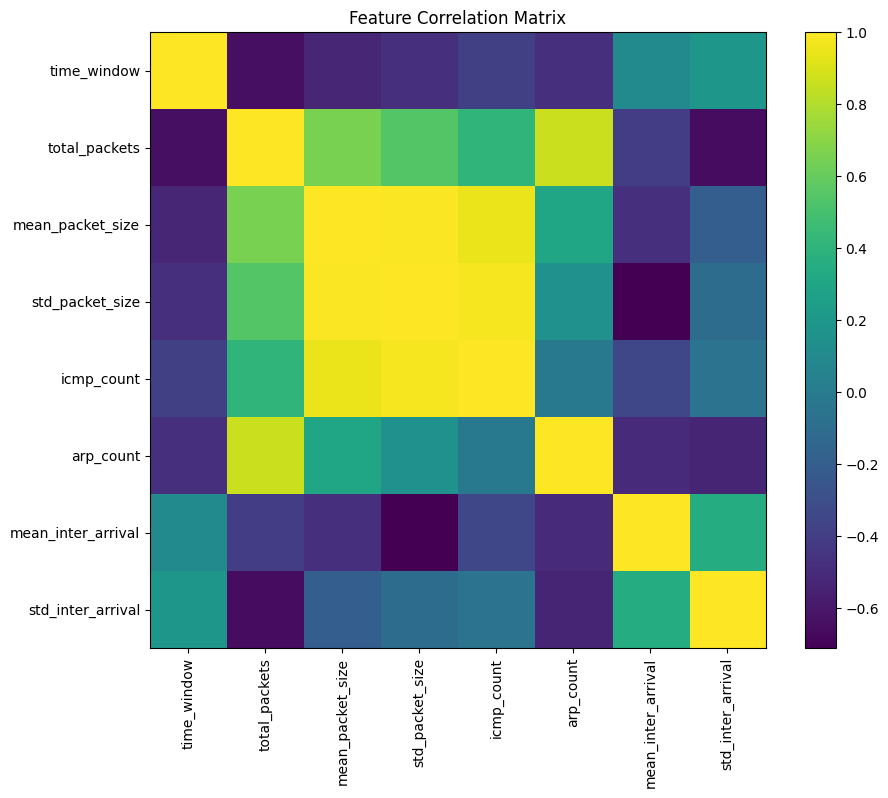

In [16]:
# Correlation matrix

correlation_matrix = normal_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")

plt.show()

The correlation matrix reveals that several packet-related features are strongly correlated, particularly those describing packet size and traffic intensity.

In contrast, temporal features such as the inter-arrival time exhibit weaker or negative correlations with packet-count metrics, indicating that they provide complementary information. Overall, the extracted features capture different aspects of network behaviour and are suitable for anomaly detection tasks.

## Loading Multiple Anomalous Traffic Scenarios

To extend the analysis beyond a single anomaly type, additional anomalous traffic datasets are loaded.

These datasets represent different network behaviours and will be used in the following sections to compare traffic patterns across multiple anomaly scenarios.

In [23]:
# Load additional anomalous datasets

reconnections_df = pd.read_csv("../data/datasets/reinicios_simulados_industrial_dataset.csv")

no_enrutable_df = pd.read_csv("../data/datasets/destino_no_enrutable_industrial_dataset.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


The datasets were successfully loaded and are ready for comparative analysis. The following visualizations examine how different anomalous scenarios affect network traffic characteristics.

## Multi-Scenario Traffic Comparison

The following figure compares packet volume over time for the normal traffic dataset and several anomalous network scenarios generated during the experiments.

Comparing multiple scenarios provides a clearer understanding of how different network events affect traffic behaviour and whether each anomaly produces a distinctive traffic pattern.

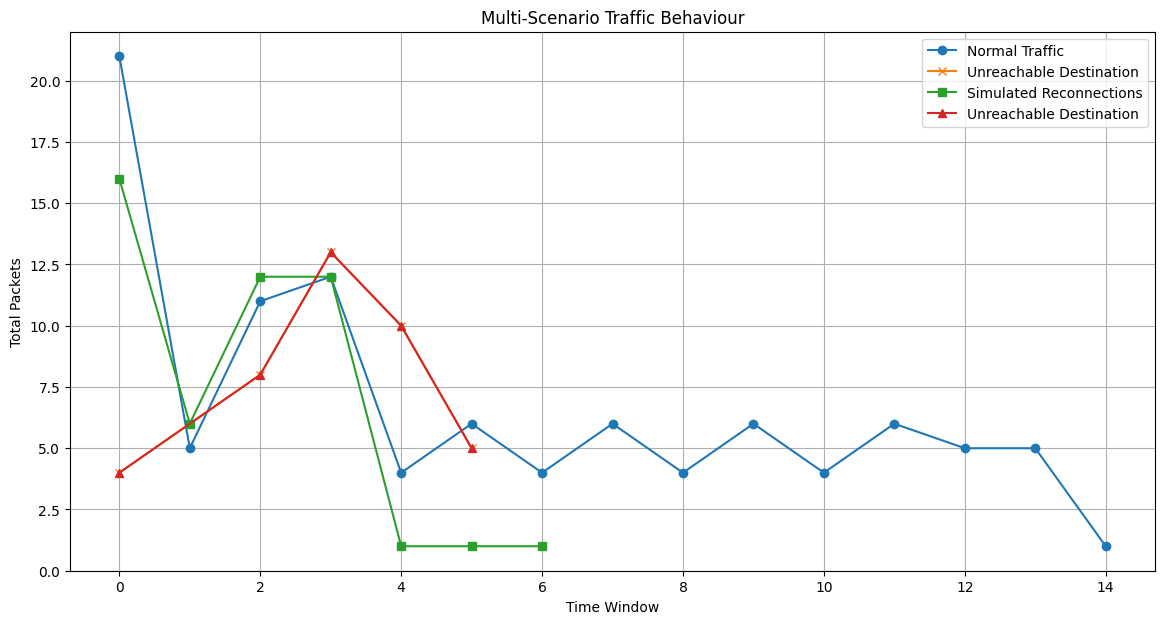

In [25]:
# Multi-scenario comparison

plt.figure(figsize=(14, 7))

plt.plot(
    normal_df["time_window"],
    normal_df["total_packets"],
    marker="o",
    label="Normal Traffic"
)

plt.plot(
    anomaly_df["time_window"],
    anomaly_df["total_packets"],
    marker="x",
    label="Unreachable Destination"
)

plt.plot(
    reconnections_df["time_window"],
    reconnections_df["total_packets"],
    marker="s",
    label="Simulated Reconnections"
)

plt.plot(
    no_enrutable_df["time_window"],
    no_enrutable_df["total_packets"],
    marker="^",
    label="Unreachable Destination"
)

plt.title("Multi-Scenario Traffic Behaviour")
plt.xlabel("Time Window")
plt.ylabel("Total Packets")

plt.legend()
plt.grid(True)

plt.show()

### Results

The comparison highlights clear behavioural differences between the analysed traffic scenarios.

Normal traffic remains relatively stable throughout the observation period, showing only moderate fluctuations in packet volume. In contrast, the anomalous scenarios exhibit more irregular behaviour.

The unreachable destination scenario generates higher packet counts during the initial windows before gradually decreasing, while the simulated reconnection scenario produces a short burst of activity followed by a rapid drop in traffic. These behaviours differ noticeably from the baseline traffic.

Overall, the results suggest that different anomaly types generate distinguishable temporal patterns, supporting the use of statistical traffic features for Machine Learning-based anomaly detection.

## Observations and Conclusions

This exploratory analysis provided an initial understanding of the IoT traffic datasets generated throughout the project.

The comparison between normal and anomalous scenarios revealed noticeable differences in packet volume and temporal behaviour. While normal traffic generally exhibited stable communication patterns, each anomaly introduced distinctive variations that were reflected in the extracted traffic features. Statistical summaries and feature correlation analysis also highlighted differences that may contribute to distinguishing normal and anomalous network behaviour.

Although these observations are based on a limited set of simulated scenarios, they demonstrate the potential of the selected features for supporting Machine Learning-based anomaly detection. The exploratory analysis presented in this notebook therefore served as the foundation for the preprocessing pipeline, feature engineering process and model development described in the main project.